# Mentoría PDIS — Notebook 02
# Aprendizaje No Supervisado — versión Low-RAM
## K-Means + DBSCAN + HDBSCAN
### Olaroz ↔ Hombre Muerto

Este notebook continúa desde el **Notebook 01** y usa los tres Data Marts allí generados.

## Regla crítica

La unidad indivisible de partición es `polygon_id`.

**Todos los píxeles de un mismo polígono deben permanecer en el mismo split.**

Nunca se realiza un split aleatorio puro por píxel.

## Objetivos

- comparar K-Means, DBSCAN y HDBSCAN;
- comparar los tres Data Marts;
- seleccionar parámetros usando solamente TRAIN;
- medir estructura interna de clusters;
- comparar los clusters con las clases reales únicamente después del clustering;
- medir cuánto representan clase vs dominio;
- estudiar estabilidad/replicación en TEST;
- mantener trazabilidad por `polygon_id`.

## Evaluación

### Interna
- Silhouette
- Calinski-Harabasz
- Davies-Bouldin
- número de clusters
- fracción de ruido

### Externa
- ARI
- NMI
- Homogeneity
- Completeness
- V-measure
- Purity

### Dominio
Se compara:

`NMI(cluster, clase)` vs `NMI(cluster, salar)`

Buscamos, en general, clusters más ligados a clase que a dominio.

## 0. Dependencias

```bash
pip install pandas numpy matplotlib scikit-learn pyarrow hdbscan
```

El notebook usa `sklearn.cluster.HDBSCAN` si está disponible.  
Si no, usa el paquete externo `hdbscan`.

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 150)

## 0.1 Importación robusta de HDBSCAN

In [2]:
HDBSCAN_BACKEND = None

try:
    from sklearn.cluster import HDBSCAN as HDBSCANModel
    HDBSCAN_BACKEND = "sklearn"

except ImportError:
    try:
        from hdbscan import HDBSCAN as HDBSCANModel
        HDBSCAN_BACKEND = "hdbscan"

    except ImportError as exc:
        raise ImportError(
            "HDBSCAN no está disponible. Instale una versión reciente "
            "de scikit-learn o ejecute: pip install hdbscan"
        ) from exc

print("Backend HDBSCAN:", HDBSCAN_BACKEND)

Backend HDBSCAN: sklearn


# 1. Configuración

In [3]:
DATA_DIR = Path("outputs_datamarts")

DM1_PATH = DATA_DIR / "data_mart_01_fisico_completo.parquet"
DM2_PATH = DATA_DIR / "data_mart_02_indices_compacto.parquet"
DM3_PATH = DATA_DIR / "data_mart_03_contexto_espacial.parquet"

METADATA_PATH = DATA_DIR / "metadata_datamarts.json"

OUTPUT_DIR = Path("outputs_unsupervised")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "sample_id"
GROUP_COL = "polygon_id"
DOMAIN_COL = "salar"
TARGET_COL = "clase"

TEST_SIZE = 0.25
PCA_VARIANCE = 0.95
SILHOUETTE_SAMPLE_SIZE = 5000

K_VALUES = list(range(2, 9))

DBSCAN_MIN_SAMPLES_VALUES = [10, 20]
DBSCAN_EPS_QUANTILES = [0.90, 0.95, 0.975, 0.99]

HDBSCAN_MIN_CLUSTER_SIZE_VALUES = [100, 250, 500]
HDBSCAN_MIN_SAMPLES_VALUES = [10, 20]

MAX_PLOT_SAMPLES = 12000

# 1.1 Modo Low-RAM: muestreo inteligente opcional

Si estás trabajando en una notebook con **12 GB de RAM** o un procesador modesto, conviene reducir la cantidad de píxeles antes de ejecutar DBSCAN/HDBSCAN.

La idea **no** es hacer un `df.sample(...)` global, porque eso puede dejar polígonos sin representación, alterar el balance entre clases y dominios y favorecer polígonos grandes.

En cambio usamos un muestreo jerárquico:

```text
salar
  ↓
clase
  ↓
polygon_id
  ↓
muestreo dentro del polígono
```

Cada polígono conserva representación y se limita a un máximo de píxeles. Dentro de cada polígono se intenta cubrir distintos cuantiles de una variable de diversidad espectral (`eng_brightness` cuando está disponible).

## Recomendación para 12 GB RAM

```python
USE_INTELLIGENT_SAMPLE = True
MAX_SAMPLES_PER_POLYGON = 250
```

Con 48 polígonos, el máximo aproximado sería **12.000 muestras**, mucho más manejable para métodos de densidad.

In [4]:
# MODO LOW-RAM / SAMPLE INTELIGENTE

USE_INTELLIGENT_SAMPLE = True

# Máximo de píxeles retenidos por polygon_id.
MAX_SAMPLES_PER_POLYGON = 1000

# Cantidad de estratos internos por polígono.
N_INTERNAL_BINS = 5

# Se usa la primera variable disponible como proxy de diversidad.
DIVERSITY_FEATURE_CANDIDATES = [
    "eng_brightness",
    "eng_visible_mean",
    "feat_BSI",
    "feat_NDVI",
    "spec_B04",
]

SAMPLE_RANDOM_STATE = 42

## 1.2 Funciones de muestreo inteligente

El sample se calcula una sola vez sobre DM1 y se reutilizan exactamente los mismos `sample_id` en DM2 y DM3. Así la comparación entre Data Marts es justa.

In [5]:
def choose_diversity_feature(data: pd.DataFrame, candidates: list[str]) -> str | None:
    """Devuelve la primera variable disponible útil como proxy de diversidad."""
    for feature in candidates:
        if feature in data.columns:
            return feature
    return None


def smart_sample_polygon(
    polygon_df: pd.DataFrame,
    max_samples: int,
    n_bins: int,
    diversity_feature: str | None,
    random_state: int,
) -> pd.DataFrame:
    """
    Muestrea un único polígono de forma reproducible.

    Si el polígono supera max_samples, intenta distribuir la muestra
    entre cuantiles de una variable de diversidad espectral.
    """

    if len(polygon_df) <= max_samples:
        return polygon_df.copy()

    if diversity_feature is None:
        return polygon_df.sample(n=max_samples, random_state=random_state).copy()

    work = polygon_df.copy()

    try:
        work["_sample_bin"] = pd.qcut(
            work[diversity_feature],
            q=n_bins,
            labels=False,
            duplicates="drop",
        )
    except ValueError:
        return work.sample(n=max_samples, random_state=random_state).copy()

    valid_bins = sorted(work["_sample_bin"].dropna().unique().tolist())

    if not valid_bins:
        return work.sample(n=max_samples, random_state=random_state).copy()

    per_bin = max(1, max_samples // len(valid_bins))
    selected_parts = []

    for bin_id in valid_bins:
        bin_df = work[work["_sample_bin"] == bin_id]
        n_take = min(len(bin_df), per_bin)

        selected_parts.append(
            bin_df.sample(
                n=n_take,
                random_state=random_state + int(bin_id) + 1,
            )
        )

    selected = pd.concat(selected_parts, axis=0)

    missing = max_samples - len(selected)

    if missing > 0:
        remaining = work.loc[~work.index.isin(selected.index)]

        if len(remaining) > 0:
            extra = remaining.sample(
                n=min(missing, len(remaining)),
                random_state=random_state + 1000,
            )
            selected = pd.concat([selected, extra], axis=0)

    return (
        selected
        .drop(columns=["_sample_bin"], errors="ignore")
        .sample(frac=1.0, random_state=random_state)
    )


def intelligent_group_sample(
    data: pd.DataFrame,
    max_samples_per_polygon: int = 250,
    n_bins: int = 5,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Conserva todos los polygon_id y limita cuántos píxeles aporta cada uno.
    """

    diversity_feature = choose_diversity_feature(
        data=data,
        candidates=DIVERSITY_FEATURE_CANDIDATES,
    )

    print("Variable usada para diversidad:", diversity_feature)

    sampled_parts = []

    for i, (_, polygon_df) in enumerate(data.groupby(GROUP_COL, sort=True)):
        sampled_polygon = smart_sample_polygon(
            polygon_df=polygon_df,
            max_samples=max_samples_per_polygon,
            n_bins=n_bins,
            diversity_feature=diversity_feature,
            random_state=random_state + i,
        )
        sampled_parts.append(sampled_polygon)

    sampled = pd.concat(sampled_parts, axis=0)

    return (
        sampled
        .sort_values([DOMAIN_COL, TARGET_COL, GROUP_COL, ID_COL])
        .reset_index(drop=True)
    )


def apply_same_sample_ids(data: pd.DataFrame, sample_ids: set[str]) -> pd.DataFrame:
    """Filtra un Data Mart usando exactamente los mismos sample_id."""
    return data[data[ID_COL].astype(str).isin(sample_ids)].copy()


def audit_sampling(original: pd.DataFrame, sampled: pd.DataFrame) -> pd.DataFrame:
    """Compara cobertura antes y después del sample."""
    rows = []

    for name, current in [("original", original), ("sampled", sampled)]:
        rows.append({
            "dataset": name,
            "n_samples": len(current),
            "n_polygons": current[GROUP_COL].nunique(),
            "n_domains": current[DOMAIN_COL].nunique(),
            "n_classes": current[TARGET_COL].nunique(),
        })

    return pd.DataFrame(rows)

# 2. Carga de los tres Data Marts

In [6]:
def load_parquet_or_csv(parquet_path: Path) -> pd.DataFrame:
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)

    csv_path = parquet_path.with_suffix(".csv")

    if csv_path.exists():
        return pd.read_csv(csv_path)

    raise FileNotFoundError(
        f"No se encontró {parquet_path} ni {csv_path}"
    )


data_mart_01 = load_parquet_or_csv(DM1_PATH)
data_mart_02 = load_parquet_or_csv(DM2_PATH)
data_mart_03 = load_parquet_or_csv(DM3_PATH)

print("DM1:", data_mart_01.shape)
print("DM2:", data_mart_02.shape)
print("DM3:", data_mart_03.shape)

DM1: (38621, 41)
DM2: (38621, 31)
DM3: (38621, 47)


In [7]:
# ============================================================
# APLICAR MUESTREO INTELIGENTE SI ESTÁ HABILITADO
# ============================================================

if USE_INTELLIGENT_SAMPLE:

    original_dm1 = data_mart_01.copy()

    sampled_dm1 = intelligent_group_sample(
        data=data_mart_01,
        max_samples_per_polygon=MAX_SAMPLES_PER_POLYGON,
        n_bins=N_INTERNAL_BINS,
        random_state=SAMPLE_RANDOM_STATE,
    )

    selected_sample_ids = set(sampled_dm1[ID_COL].astype(str).tolist())

    data_mart_01 = sampled_dm1
    data_mart_02 = apply_same_sample_ids(data_mart_02, selected_sample_ids)
    data_mart_03 = apply_same_sample_ids(data_mart_03, selected_sample_ids)

    # Control fuerte: los tres marts deben tener exactamente los mismos IDs.
    ids_dm1 = set(data_mart_01[ID_COL].astype(str))
    ids_dm2 = set(data_mart_02[ID_COL].astype(str))
    ids_dm3 = set(data_mart_03[ID_COL].astype(str))

    assert ids_dm1 == ids_dm2 == ids_dm3

    print("\nMuestreo inteligente aplicado.")
    display(audit_sampling(original_dm1, data_mart_01))

    print("\nMuestras por polígono después del sample:")
    display(
        data_mart_01
        .groupby([DOMAIN_COL, TARGET_COL, GROUP_COL])
        .size()
        .rename("n_samples")
        .reset_index()
        .sort_values([DOMAIN_COL, TARGET_COL, GROUP_COL])
    )

else:
    print(
        "USE_INTELLIGENT_SAMPLE=False -> "
        "se utilizará el dataset completo."
    )

Variable usada para diversidad: eng_brightness

Muestreo inteligente aplicado.


,dataset,n_samples,n_polygons,n_domains,n_classes
0,original,38621,48,2,4
1,sampled,38621,48,2,4



Muestras por polígono después del sample:


,salar,clase,polygon_id,n_samples
0,hombre_muerto,agua_humedad,HOM_AGU_001,768
1,hombre_muerto,agua_humedad,HOM_AGU_002,769
2,hombre_muerto,agua_humedad,HOM_AGU_003,252
3,hombre_muerto,agua_humedad,HOM_AGU_004,503
4,hombre_muerto,agua_humedad,HOM_AGU_005,267
5,hombre_muerto,agua_humedad,HOM_AGU_006,625
6,hombre_muerto,salina,HOM_SAL_001,236
7,hombre_muerto,salina,HOM_SAL_002,736
8,hombre_muerto,salina,HOM_SAL_003,108
9,hombre_muerto,salina,HOM_SAL_004,417


In [8]:
with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

display(pd.Series(metadata, name="valor").to_frame())

,valor
dataset_name,salares_ml_curated_datamarts
source_metadata,"{'dataset': 'dataset_salares_ml', 'salares': [..."
random_state,42
id_column,sample_id
group_column,polygon_id
domain_column,salar
target_column,clase
domains,"[hombre_muerto, olaroz]"
classes,"[agua_humedad, salina, suelo_desnudo, suelo_ro..."
n_samples,38621


# 3. Recuperar features oficiales de cada Data Mart

In [9]:
data_mart_specs = {
    "DM1_fisico_completo": {
        "data": data_mart_01,
        "features": metadata["data_marts"]["DM1_fisico_completo"]["features"],
    },
    "DM2_indices_compacto": {
        "data": data_mart_02,
        "features": metadata["data_marts"]["DM2_indices_compacto"]["features"],
    },
    "DM3_contexto_espacial": {
        "data": data_mart_03,
        "features": metadata["data_marts"]["DM3_contexto_espacial"]["features"],
    },
}

for mart_name, spec in data_mart_specs.items():
    missing = [
        feature
        for feature in spec["features"]
        if feature not in spec["data"].columns
    ]

    if missing:
        raise ValueError(
            f"{mart_name}: faltan features {missing}"
        )

    print(
        mart_name,
        "->",
        len(spec["features"]),
        "features",
    )

DM1_fisico_completo -> 27 features
DM2_indices_compacto -> 17 features
DM3_contexto_espacial -> 33 features


## Nota sobre sample y split

El sample inteligente reduce píxeles **dentro de cada polígono**, pero conserva todos los `polygon_id`. Luego se construye TRAIN/TEST a nivel de polígono.

```text
sample inteligente
    ↓
todos los polígonos siguen presentes
    ↓
split por polygon_id
    ↓
0 polígonos compartidos entre TRAIN y TEST
```

Por lo tanto, el sample no introduce fuga espacial.

# 4. Split seguro por `polygon_id`

El split se construye en una tabla con **una fila por polígono**.

Se estratifica por `salar + clase` solo para mantener representatividad experimental.  
La clase no participa en el clustering.

In [10]:
def build_group_safe_split(
    data: pd.DataFrame,
    test_size: float = 0.25,
    random_state: int = 42,
) -> tuple[set[str], set[str], pd.DataFrame]:

    polygon_table = (
        data[
            [GROUP_COL, DOMAIN_COL, TARGET_COL]
        ]
        .drop_duplicates()
        .copy()
    )

    duplicated_group = polygon_table[GROUP_COL].duplicated(keep=False)

    if duplicated_group.any():
        display(
            polygon_table[duplicated_group]
            .sort_values(GROUP_COL)
        )
        raise ValueError(
            "Un polygon_id aparece asociado a más de una clase o dominio."
        )

    polygon_table["stratum"] = (
        polygon_table[DOMAIN_COL].astype(str)
        + "__"
        + polygon_table[TARGET_COL].astype(str)
    )

    train_groups, test_groups = train_test_split(
        polygon_table[GROUP_COL],
        test_size=test_size,
        random_state=random_state,
        stratify=polygon_table["stratum"],
    )

    train_groups = set(train_groups.astype(str).tolist())
    test_groups = set(test_groups.astype(str).tolist())

    if train_groups & test_groups:
        raise RuntimeError("Se detectó fuga de polygon_id.")

    polygon_table["split"] = np.where(
        polygon_table[GROUP_COL].isin(train_groups),
        "train",
        "test",
    )

    return train_groups, test_groups, polygon_table

In [11]:
TRAIN_GROUPS, TEST_GROUPS, split_polygons = build_group_safe_split(
    data=data_mart_01,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

display(
    split_polygons.sort_values(
        ["split", DOMAIN_COL, TARGET_COL, GROUP_COL]
    )
)

print("Polígonos TRAIN:", len(TRAIN_GROUPS))
print("Polígonos TEST :", len(TEST_GROUPS))
print("Intersección   :", TRAIN_GROUPS & TEST_GROUPS)

,polygon_id,salar,clase,stratum,split
768,HOM_AGU_002,hombre_muerto,agua_humedad,hombre_muerto__agua_humedad,test
4681,HOM_SAL_005,hombre_muerto,salina,hombre_muerto__salina,test
6231,HOM_DES_002,hombre_muerto,suelo_desnudo,hombre_muerto__suelo_desnudo,test
9231,HOM_DES_005,hombre_muerto,suelo_desnudo,hombre_muerto__suelo_desnudo,test
12231,HOM_ROC_002,hombre_muerto,suelo_rocoso,hombre_muerto__suelo_rocoso,test
14231,HOM_ROC_004,hombre_muerto,suelo_rocoso,hombre_muerto__suelo_rocoso,test
18231,OLA_AGU_002,olaroz,agua_humedad,olaroz__agua_humedad,test
20404,OLA_AGU_005,olaroz,agua_humedad,olaroz__agua_humedad,test
23645,OLA_SAL_003,olaroz,salina,olaroz__salina,test
29621,OLA_DES_004,olaroz,suelo_desnudo,olaroz__suelo_desnudo,test


Polígonos TRAIN: 36
Polígonos TEST : 12
Intersección   : set()


In [12]:
split_balance = (
    split_polygons
    .groupby(["split", DOMAIN_COL, TARGET_COL])
    .size()
    .rename("n_polygons")
    .reset_index()
)

display(split_balance)

,split,salar,clase,n_polygons
0,test,hombre_muerto,agua_humedad,1
1,test,hombre_muerto,salina,1
2,test,hombre_muerto,suelo_desnudo,2
3,test,hombre_muerto,suelo_rocoso,2
4,test,olaroz,agua_humedad,2
5,test,olaroz,salina,1
6,test,olaroz,suelo_desnudo,2
7,test,olaroz,suelo_rocoso,1
8,train,hombre_muerto,agua_humedad,5
9,train,hombre_muerto,salina,5


# 5. Separar TRAIN y TEST sin fuga espacial

In [13]:
def apply_group_split(
    data: pd.DataFrame,
    train_groups: set[str],
    test_groups: set[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train_df = (
        data[
            data[GROUP_COL].astype(str).isin(train_groups)
        ]
        .copy()
    )

    test_df = (
        data[
            data[GROUP_COL].astype(str).isin(test_groups)
        ]
        .copy()
    )

    train_ids = set(train_df[GROUP_COL].astype(str).unique())
    test_ids = set(test_df[GROUP_COL].astype(str).unique())

    assert not (train_ids & test_ids)

    return train_df, test_df

# 6. Preprocesamiento sin leakage

`StandardScaler` y `PCA` se ajustan solo con TRAIN.

TEST únicamente se transforma.

In [14]:
@dataclass
class PreparedData:
    train_df: pd.DataFrame
    test_df: pd.DataFrame
    feature_columns: list[str]

    scaler: StandardScaler
    pca: PCA

    X_train_scaled: np.ndarray
    X_test_scaled: np.ndarray

    X_train_cluster: np.ndarray
    X_test_cluster: np.ndarray


def prepare_data(
    data: pd.DataFrame,
    feature_columns: list[str],
) -> PreparedData:

    train_df, test_df = apply_group_split(
        data=data,
        train_groups=TRAIN_GROUPS,
        test_groups=TEST_GROUPS,
    )

    X_train = train_df[feature_columns].to_numpy(dtype=float)
    X_test = test_df[feature_columns].to_numpy(dtype=float)

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(
        n_components=PCA_VARIANCE,
        svd_solver="full",
    )

    X_train_cluster = pca.fit_transform(X_train_scaled)
    X_test_cluster = pca.transform(X_test_scaled)

    return PreparedData(
        train_df=train_df,
        test_df=test_df,
        feature_columns=feature_columns,
        scaler=scaler,
        pca=pca,
        X_train_scaled=X_train_scaled,
        X_test_scaled=X_test_scaled,
        X_train_cluster=X_train_cluster,
        X_test_cluster=X_test_cluster,
    )

# 7. Métricas

In [15]:
def cluster_purity(
    y_true: np.ndarray,
    cluster_labels: np.ndarray,
) -> float:

    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)

    valid_mask = cluster_labels != -1

    if not valid_mask.any():
        return np.nan

    y = y_true[valid_mask]
    clusters = cluster_labels[valid_mask]

    majority_sum = 0

    for cluster_id in np.unique(clusters):
        values = y[clusters == cluster_id]
        counts = pd.Series(values).value_counts()
        majority_sum += int(counts.iloc[0])

    return majority_sum / len(y)

In [16]:
def internal_metrics(
    X: np.ndarray,
    labels: np.ndarray,
) -> dict:

    labels = np.asarray(labels)

    valid_mask = labels != -1

    X_valid = X[valid_mask]
    labels_valid = labels[valid_mask]

    unique_clusters = np.unique(labels_valid)
    n_clusters = len(unique_clusters)

    noise_fraction = float(
        np.mean(labels == -1)
    )

    if n_clusters < 2 or len(X_valid) <= n_clusters:
        return {
            "n_clusters": n_clusters,
            "noise_fraction": noise_fraction,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }

    sample_size = min(
        SILHOUETTE_SAMPLE_SIZE,
        len(X_valid),
    )

    silhouette = silhouette_score(
        X_valid,
        labels_valid,
        sample_size=sample_size,
        random_state=RANDOM_STATE,
    )

    return {
        "n_clusters": n_clusters,
        "noise_fraction": noise_fraction,
        "silhouette": float(silhouette),
        "calinski_harabasz": float(
            calinski_harabasz_score(
                X_valid,
                labels_valid,
            )
        ),
        "davies_bouldin": float(
            davies_bouldin_score(
                X_valid,
                labels_valid,
            )
        ),
    }

In [17]:
def external_metrics(
    data: pd.DataFrame,
    labels: np.ndarray,
) -> dict:

    y_class = data[TARGET_COL].astype(str).to_numpy()
    y_domain = data[DOMAIN_COL].astype(str).to_numpy()

    labels = np.asarray(labels)

    valid_mask = labels != -1

    if not valid_mask.any():
        return {
            "ari_class": np.nan,
            "nmi_class": np.nan,
            "homogeneity": np.nan,
            "completeness": np.nan,
            "v_measure": np.nan,
            "purity": np.nan,
            "nmi_domain": np.nan,
            "semantic_minus_domain_nmi": np.nan,
        }

    y_class_valid = y_class[valid_mask]
    y_domain_valid = y_domain[valid_mask]
    labels_valid = labels[valid_mask]

    nmi_class = normalized_mutual_info_score(
        y_class_valid,
        labels_valid,
    )

    nmi_domain = normalized_mutual_info_score(
        y_domain_valid,
        labels_valid,
    )

    return {
        "ari_class": float(
            adjusted_rand_score(
                y_class_valid,
                labels_valid,
            )
        ),
        "nmi_class": float(nmi_class),
        "homogeneity": float(
            homogeneity_score(
                y_class_valid,
                labels_valid,
            )
        ),
        "completeness": float(
            completeness_score(
                y_class_valid,
                labels_valid,
            )
        ),
        "v_measure": float(
            v_measure_score(
                y_class_valid,
                labels_valid,
            )
        ),
        "purity": float(
            cluster_purity(
                y_class_valid,
                labels_valid,
            )
        ),
        "nmi_domain": float(nmi_domain),
        "semantic_minus_domain_nmi": float(
            nmi_class - nmi_domain
        ),
    }

In [18]:
def evaluate_clustering(
    X: np.ndarray,
    data: pd.DataFrame,
    labels: np.ndarray,
) -> dict:

    return {
        **internal_metrics(X, labels),
        **external_metrics(data, labels),
    }

# 8. K-Means

In [19]:
def search_kmeans(
    X_train: np.ndarray,
) -> pd.DataFrame:

    rows = []

    for k in K_VALUES:
        model = KMeans(
            n_clusters=k,
            n_init="auto",
            random_state=RANDOM_STATE,
        )

        labels = model.fit_predict(X_train)

        metrics = internal_metrics(
            X_train,
            labels,
        )

        rows.append(
            {
                "k": k,
                **metrics,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(
            "silhouette",
            ascending=False,
        )
        .reset_index(drop=True)
    )

# 9. DBSCAN

In [20]:
def dbscan_eps_candidates(
    X_train: np.ndarray,
    min_samples: int,
) -> list[float]:

    neighbors = NearestNeighbors(
        n_neighbors=min_samples
    )

    neighbors.fit(X_train)

    distances, _ = neighbors.kneighbors(
        X_train
    )

    kth_distance = distances[:, -1]

    candidates = [
        float(
            np.quantile(
                kth_distance,
                q,
            )
        )
        for q in DBSCAN_EPS_QUANTILES
    ]

    return sorted(set(candidates))

In [21]:
def search_dbscan(
    X_train: np.ndarray,
) -> pd.DataFrame:

    rows = []

    for min_samples in DBSCAN_MIN_SAMPLES_VALUES:

        eps_values = dbscan_eps_candidates(
            X_train,
            min_samples,
        )

        for eps in eps_values:

            model = DBSCAN(
                eps=eps,
                min_samples=min_samples,
                n_jobs=-1,
            )

            labels = model.fit_predict(
                X_train
            )

            metrics = internal_metrics(
                X_train,
                labels,
            )

            rows.append(
                {
                    "eps": eps,
                    "min_samples": min_samples,
                    **metrics,
                }
            )

    results = pd.DataFrame(rows)

    valid = results["n_clusters"] >= 2

    if valid.any():
        results = results.sort_values(
            ["silhouette", "noise_fraction"],
            ascending=[False, True],
        )
    else:
        results = results.sort_values(
            "noise_fraction"
        )

    return results.reset_index(drop=True)

# 10. HDBSCAN

In [22]:
def build_hdbscan(
    min_cluster_size: int,
    min_samples: int,
):

    if HDBSCAN_BACKEND == "sklearn":
        return HDBSCANModel(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
        )

    return HDBSCANModel(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        prediction_data=False,
    )

In [23]:
def search_hdbscan(
    X_train: np.ndarray,
) -> pd.DataFrame:

    rows = []

    for min_cluster_size in HDBSCAN_MIN_CLUSTER_SIZE_VALUES:

        for min_samples in HDBSCAN_MIN_SAMPLES_VALUES:

            model = build_hdbscan(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
            )

            labels = model.fit_predict(
                X_train
            )

            metrics = internal_metrics(
                X_train,
                labels,
            )

            rows.append(
                {
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    **metrics,
                }
            )

    results = pd.DataFrame(rows)

    valid = results["n_clusters"] >= 2

    if valid.any():
        results = results.sort_values(
            ["silhouette", "noise_fraction"],
            ascending=[False, True],
        )
    else:
        results = results.sort_values(
            "noise_fraction"
        )

    return results.reset_index(drop=True)

# 11. Experimento completo por Data Mart

In [24]:
def run_unsupervised_experiment(
    mart_name: str,
    data: pd.DataFrame,
    feature_columns: list[str],
):

    print("\n" + "=" * 80)
    print(mart_name)
    print("=" * 80)

    prepared = prepare_data(
        data=data,
        feature_columns=feature_columns,
    )

    print("TRAIN:", prepared.train_df.shape)
    print("TEST :", prepared.test_df.shape)
    print(
        "Componentes PCA:",
        prepared.X_train_cluster.shape[1],
    )
    print(
        "Varianza PCA:",
        prepared.pca.explained_variance_ratio_.sum(),
    )

    rows = []
    selected_parameters = {}
    labels_store = {}

    # --------------------------------------------------------
    # K-MEANS
    # --------------------------------------------------------

    print("\nBuscando K-Means...")

    k_search = search_kmeans(
        prepared.X_train_cluster
    )

    display(k_search)

    best_k = int(
        k_search.iloc[0]["k"]
    )

    kmeans = KMeans(
        n_clusters=best_k,
        n_init="auto",
        random_state=RANDOM_STATE,
    )

    train_labels_kmeans = kmeans.fit_predict(
        prepared.X_train_cluster
    )

    test_labels_kmeans = kmeans.predict(
        prepared.X_test_cluster
    )

    rows.append(
        {
            "data_mart": mart_name,
            "algorithm": "KMeans",
            "split": "train",
            "evaluation_mode": "fit",
            **evaluate_clustering(
                prepared.X_train_cluster,
                prepared.train_df,
                train_labels_kmeans,
            ),
        }
    )

    rows.append(
        {
            "data_mart": mart_name,
            "algorithm": "KMeans",
            "split": "test",
            "evaluation_mode": "out_of_sample_predict",
            **evaluate_clustering(
                prepared.X_test_cluster,
                prepared.test_df,
                test_labels_kmeans,
            ),
        }
    )

    selected_parameters["KMeans"] = {
        "k": best_k,
    }

    labels_store["KMeans"] = {
        "train": train_labels_kmeans,
        "test": test_labels_kmeans,
    }

    # --------------------------------------------------------
    # DBSCAN
    # --------------------------------------------------------

    print("\nBuscando DBSCAN...")

    dbscan_search = search_dbscan(
        prepared.X_train_cluster
    )

    display(dbscan_search)

    best_dbscan = dbscan_search.iloc[0]

    best_eps = float(
        best_dbscan["eps"]
    )

    best_min_samples = int(
        best_dbscan["min_samples"]
    )

    dbscan_train = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples,
        n_jobs=-1,
    )

    dbscan_test = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples,
        n_jobs=-1,
    )

    train_labels_dbscan = dbscan_train.fit_predict(
        prepared.X_train_cluster
    )

    test_labels_dbscan = dbscan_test.fit_predict(
        prepared.X_test_cluster
    )

    rows.append(
        {
            "data_mart": mart_name,
            "algorithm": "DBSCAN",
            "split": "train",
            "evaluation_mode": "fit",
            **evaluate_clustering(
                prepared.X_train_cluster,
                prepared.train_df,
                train_labels_dbscan,
            ),
        }
    )

    rows.append(
        {
            "data_mart": mart_name,
            "algorithm": "DBSCAN",
            "split": "test",
            "evaluation_mode": "structural_replication",
            **evaluate_clustering(
                prepared.X_test_cluster,
                prepared.test_df,
                test_labels_dbscan,
            ),
        }
    )

    selected_parameters["DBSCAN"] = {
        "eps": best_eps,
        "min_samples": best_min_samples,
    }

    labels_store["DBSCAN"] = {
        "train": train_labels_dbscan,
        "test": test_labels_dbscan,
    }

    # --------------------------------------------------------
    # HDBSCAN
    # --------------------------------------------------------

    print("\nBuscando HDBSCAN...")

    hdbscan_search = search_hdbscan(
        prepared.X_train_cluster
    )

    display(hdbscan_search)

    best_hdbscan = hdbscan_search.iloc[0]

    best_min_cluster_size = int(
        best_hdbscan["min_cluster_size"]
    )

    best_hdbscan_min_samples = int(
        best_hdbscan["min_samples"]
    )

    hdbscan_train = build_hdbscan(
        min_cluster_size=best_min_cluster_size,
        min_samples=best_hdbscan_min_samples,
    )

    hdbscan_test = build_hdbscan(
        min_cluster_size=best_min_cluster_size,
        min_samples=best_hdbscan_min_samples,
    )

    train_labels_hdbscan = hdbscan_train.fit_predict(
        prepared.X_train_cluster
    )

    test_labels_hdbscan = hdbscan_test.fit_predict(
        prepared.X_test_cluster
    )

    rows.append(
        {
            "data_mart": mart_name,
            "algorithm": "HDBSCAN",
            "split": "train",
            "evaluation_mode": "fit",
            **evaluate_clustering(
                prepared.X_train_cluster,
                prepared.train_df,
                train_labels_hdbscan,
            ),
        }
    )

    rows.append(
        {
            "data_mart": mart_name,
            "algorithm": "HDBSCAN",
            "split": "test",
            "evaluation_mode": "structural_replication",
            **evaluate_clustering(
                prepared.X_test_cluster,
                prepared.test_df,
                test_labels_hdbscan,
            ),
        }
    )

    selected_parameters["HDBSCAN"] = {
        "min_cluster_size": best_min_cluster_size,
        "min_samples": best_hdbscan_min_samples,
    }

    labels_store["HDBSCAN"] = {
        "train": train_labels_hdbscan,
        "test": test_labels_hdbscan,
    }

    labels_store["_prepared"] = prepared

    return (
        pd.DataFrame(rows),
        selected_parameters,
        labels_store,
    )

# 12. Ejecutar los tres Data Marts

In [25]:
all_results = []
all_parameters = {}
all_labels = {}

for mart_name, spec in data_mart_specs.items():

    results, parameters, labels = run_unsupervised_experiment(
        mart_name=mart_name,
        data=spec["data"],
        feature_columns=spec["features"],
    )

    all_results.append(results)
    all_parameters[mart_name] = parameters
    all_labels[mart_name] = labels

results_df = pd.concat(
    all_results,
    ignore_index=True,
)

display(results_df)


DM1_fisico_completo
TRAIN: (27793, 41)
TEST : (10828, 41)
Componentes PCA: 2
Varianza PCA: 0.9605805364071818

Buscando K-Means...


C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,k,n_clusters,noise_fraction,silhouette,calinski_harabasz,davies_bouldin
0,3,3,0.0,0.859471,277242.432845,0.235442
1,2,2,0.0,0.677035,30533.705475,0.436767
2,4,4,0.0,0.644744,219271.779483,0.504986
3,5,5,0.0,0.613050,256829.524261,0.544950
4,6,6,0.0,0.524500,230230.613570,0.771350
5,7,7,0.0,0.519827,250683.902486,0.797422
6,8,8,0.0,0.517065,233322.209848,0.812270



Buscando DBSCAN...


,eps,min_samples,n_clusters,noise_fraction,silhouette,calinski_harabasz,davies_bouldin
0,0.559259,20,3,0.004785,0.863248,288276.209023,0.234737
1,0.304523,20,5,0.017342,0.827901,245575.989494,0.286698
2,0.169342,20,8,0.033138,0.680475,150841.036656,0.500697
3,0.374902,10,7,0.005541,0.631928,150843.048057,0.360766
4,0.106903,20,12,0.063145,0.621394,115006.470870,0.595267
5,0.205624,10,10,0.018458,0.578546,114424.863724,0.474496
6,0.118874,10,16,0.035477,0.577310,80794.713277,0.782869
7,0.074065,10,22,0.068147,0.071198,60314.250275,0.850449


...


Buscando HDBSCAN...


C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` t

,min_cluster_size,min_samples,n_clusters,noise_fraction,silhouette,calinski_harabasz,davies_bouldin
0,100,20,19,0.044364,0.308561,14546.842745,1.810899
1,100,10,22,0.051128,0.305094,13018.086956,1.965720
2,250,20,15,0.047782,0.299599,17443.986664,2.005156
3,500,20,15,0.047782,0.299599,17443.986664,2.005156
4,250,10,18,0.038283,0.292071,14292.661435,2.264297
5,500,10,16,0.034037,0.276167,15189.983642,2.388622


C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,data_mart,algorithm,split,evaluation_mode,n_clusters,noise_fraction,silhouette,calinski_harabasz,davies_bouldin,ari_class,nmi_class,homogeneity,completeness,v_measure,purity,nmi_domain,semantic_minus_domain_nmi
0,DM1_fisico_completo,KMeans,train,fit,3,0.000000,0.859471,277242.432845,0.235442,0.593394,0.789803,0.665381,0.971459,0.789803,0.707156,0.007340,0.782464
1,DM1_fisico_completo,KMeans,test,out_of_sample_predict,3,0.000000,0.893991,163480.647873,0.153057,0.557982,0.752835,0.622515,0.952165,0.752835,0.713705,0.042405,0.710429
2,DM1_fisico_completo,DBSCAN,train,fit,3,0.004785,0.863248,288276.209023,0.234737,0.602164,0.807066,0.680469,0.991532,0.807066,0.709581,0.007358,0.799708
3,DM1_fisico_completo,DBSCAN,test,structural_replication,3,0.016901,0.906871,241471.848611,0.135113,0.567153,0.773900,0.639072,0.980829,0.773900,0.715265,0.040567,0.733332
4,DM1_fisico_completo,HDBSCAN,train,fit,6,0.088655,0.605490,237416.066355,0.506543,0.566226,0.745536,0.742608,0.748487,0.745536,0.765131,0.089110,0.656426
5,DM1_fisico_completo,HDBSCAN,test,structural_replication,6,0.240949,0.796945,147169.696586,0.361376,0.650623,0.798985,0.961274,0.683579,0.798985,0.990388,0.335172,0.463814
6,DM2_indices_compacto,KMeans,train,fit,3,0.000000,0.872598,296860.003192,0.222838,0.594566,0.790941,0.666515,0.972486,0.790941,0.707444,0.007445,0.783496
7,DM2_indices_compacto,KMeans,test,out_of_sample_predict,3,0.000000,0.901947,189503.506765,0.135161,0.558489,0.751666,0.621776,0.950156,0.751666,0.713613,0.042586,0.709080
8,DM2_indices_compacto,DBSCAN,train,fit,4,0.017666,0.837995,362708.964877,0.297512,0.569525,0.777890,0.682534,0.904217,0.777890,0.706871,0.027889,0.750001
9,DM2_indices_compacto,DBSCAN,test,structural_replication,4,0.030015,0.836031,241365.979031,0.302827,0.560032,0.771467,0.641373,0.967763,0.771467,0.713415,0.043683,0.727784


# 13. Comparación general

In [26]:
comparison_columns = [
    "data_mart",
    "algorithm",
    "split",
    "evaluation_mode",
    "n_clusters",
    "noise_fraction",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "ari_class",
    "nmi_class",
    "purity",
    "nmi_domain",
    "semantic_minus_domain_nmi",
]

display(
    results_df[
        comparison_columns
    ]
    .sort_values(
        ["split", "nmi_class"],
        ascending=[True, False],
    )
)

,data_mart,algorithm,split,evaluation_mode,n_clusters,noise_fraction,silhouette,calinski_harabasz,davies_bouldin,ari_class,nmi_class,purity,nmi_domain,semantic_minus_domain_nmi
5,DM1_fisico_completo,HDBSCAN,test,structural_replication,6,0.240949,0.796945,147169.696586,0.361376,0.650623,0.798985,0.990388,0.335172,0.463814
3,DM1_fisico_completo,DBSCAN,test,structural_replication,3,0.016901,0.906871,241471.848611,0.135113,0.567153,0.773900,0.715265,0.040567,0.733332
9,DM2_indices_compacto,DBSCAN,test,structural_replication,4,0.030015,0.836031,241365.979031,0.302827,0.560032,0.771467,0.713415,0.043683,0.727784
11,DM2_indices_compacto,HDBSCAN,test,structural_replication,7,0.301071,0.700552,445556.923084,0.416224,0.563237,0.755776,0.983747,0.363040,0.392736
1,DM1_fisico_completo,KMeans,test,out_of_sample_predict,3,0.000000,0.893991,163480.647873,0.153057,0.557982,0.752835,0.713705,0.042405,0.710429
13,DM3_contexto_espacial,KMeans,test,out_of_sample_predict,3,0.000000,0.703039,26560.078652,0.435045,0.557982,0.752835,0.713705,0.042405,0.710429
7,DM2_indices_compacto,KMeans,test,out_of_sample_predict,3,0.000000,0.901947,189503.506765,0.135161,0.558489,0.751666,0.713613,0.042586,0.709080
17,DM3_contexto_espacial,HDBSCAN,test,structural_replication,11,0.030015,0.250610,11259.865452,1.532272,0.487832,0.731394,1.000000,0.470519,0.260875
15,DM3_contexto_espacial,DBSCAN,test,structural_replication,7,0.017085,0.602540,11419.223343,0.700883,0.494794,0.692831,0.715588,0.268756,0.424075
2,DM1_fisico_completo,DBSCAN,train,fit,3,0.004785,0.863248,288276.209023,0.234737,0.602164,0.807066,0.709581,0.007358,0.799708


# 14. Semántica vs dominio

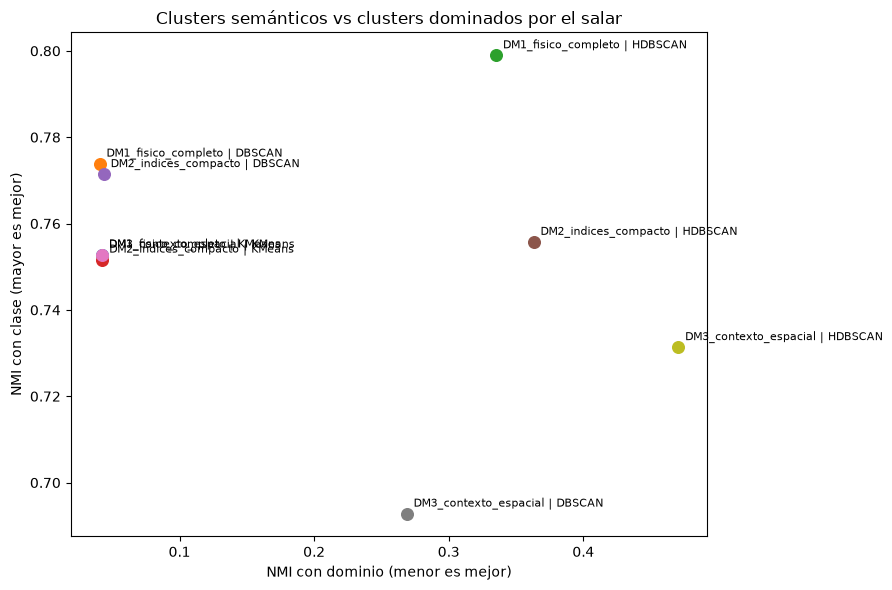

In [27]:
test_results = (
    results_df[
        results_df["split"] == "test"
    ]
    .copy()
)

plt.figure(figsize=(9, 6))

for _, row in test_results.iterrows():

    label = (
        f"{row['data_mart']} | "
        f"{row['algorithm']}"
    )

    plt.scatter(
        row["nmi_domain"],
        row["nmi_class"],
        s=70,
    )

    plt.annotate(
        label,
        (
            row["nmi_domain"],
            row["nmi_class"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel(
    "NMI con dominio (menor es mejor)"
)

plt.ylabel(
    "NMI con clase (mayor es mejor)"
)

plt.title(
    "Clusters semánticos vs clusters dominados por el salar"
)

plt.tight_layout()
plt.show()

# 15. Visualización PCA de clusters

In [28]:
def plot_clusters_pca(
    prepared: PreparedData,
    labels: np.ndarray,
    title: str,
    split: str,
):

    if split == "train":
        X = prepared.X_train_cluster

    elif split == "test":
        X = prepared.X_test_cluster

    else:
        raise ValueError(
            "split debe ser 'train' o 'test'"
        )

    if X.shape[1] < 2:
        print(
            "No hay al menos dos componentes PCA."
        )
        return

    rng = np.random.default_rng(
        RANDOM_STATE
    )

    n = len(X)

    keep = rng.choice(
        n,
        size=min(
            MAX_PLOT_SAMPLES,
            n,
        ),
        replace=False,
    )

    plt.figure(figsize=(9, 6))

    plt.scatter(
        X[keep, 0],
        X[keep, 1],
        c=np.asarray(labels)[keep],
        s=8,
        alpha=0.50,
    )

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.tight_layout()
    plt.show()

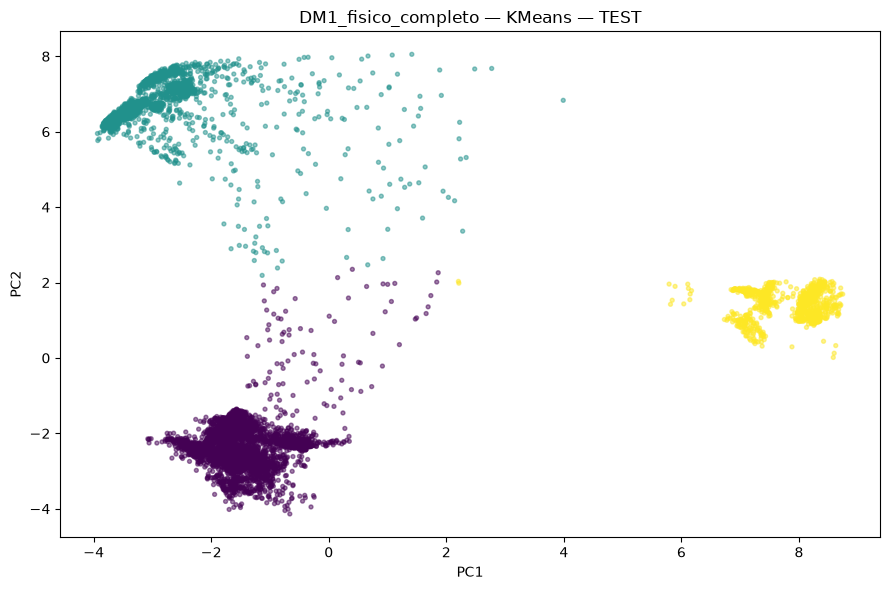

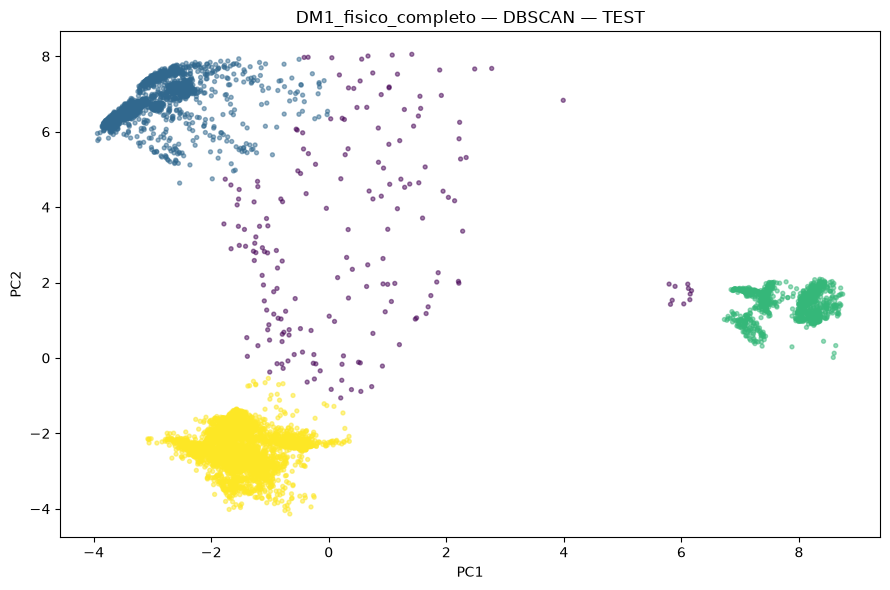

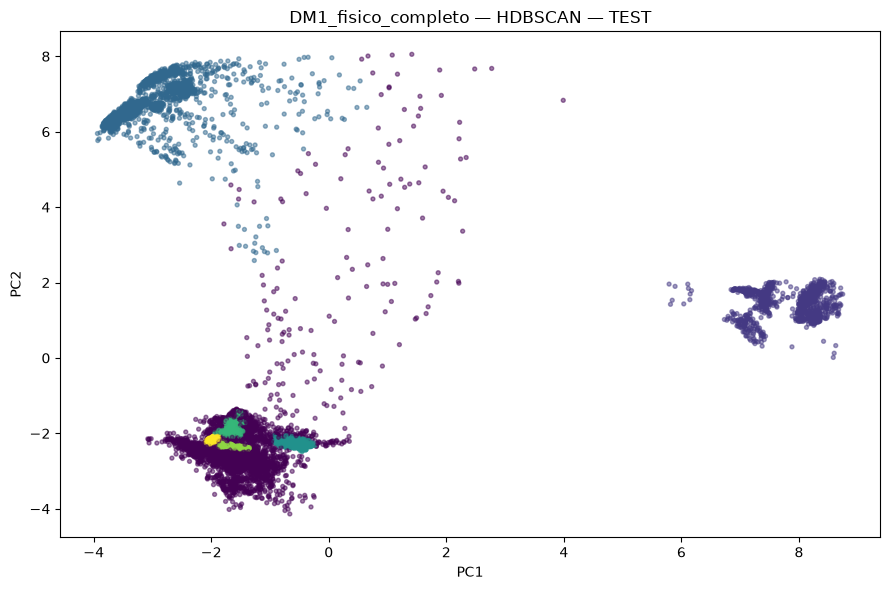

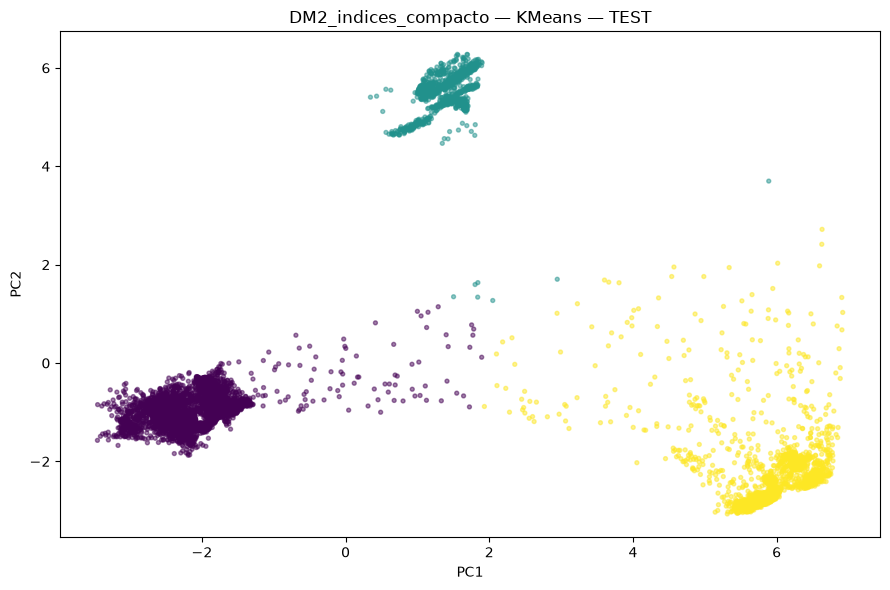

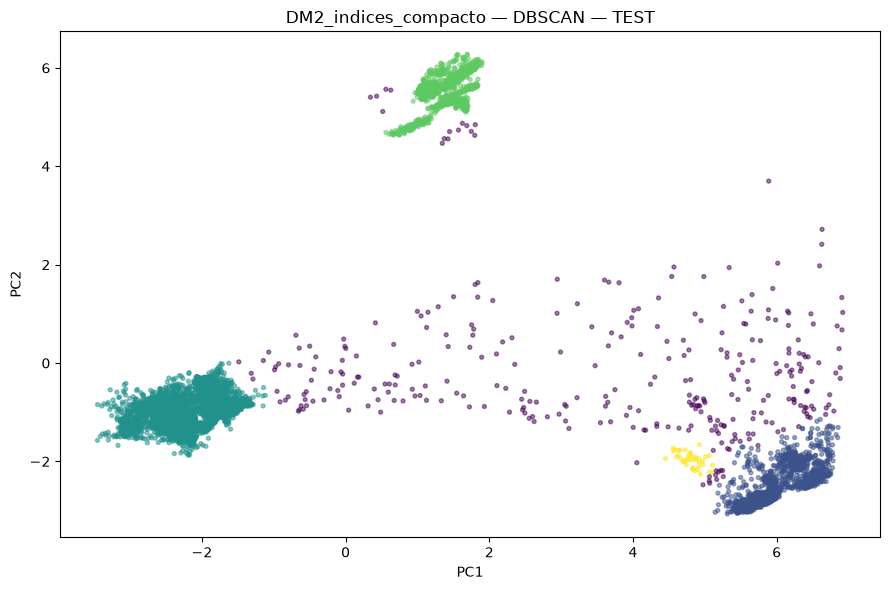

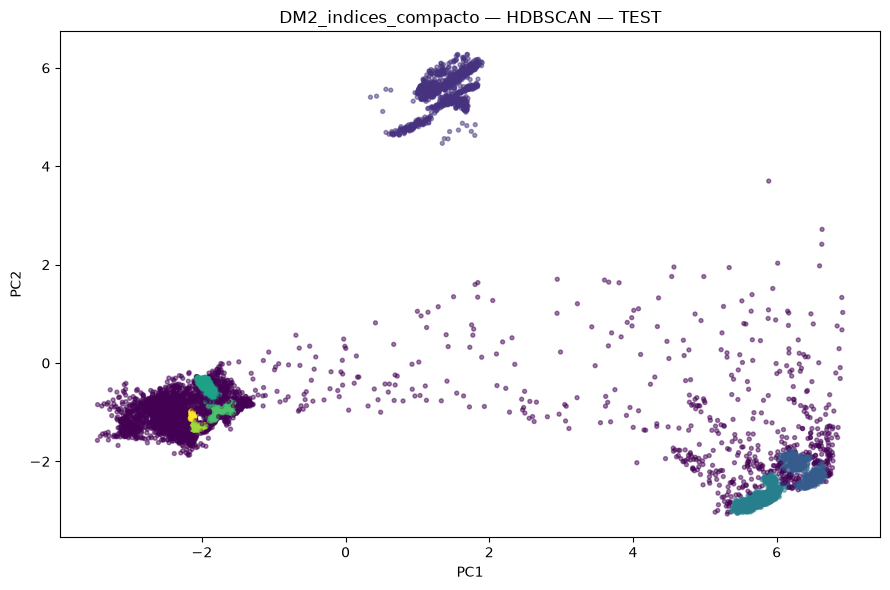

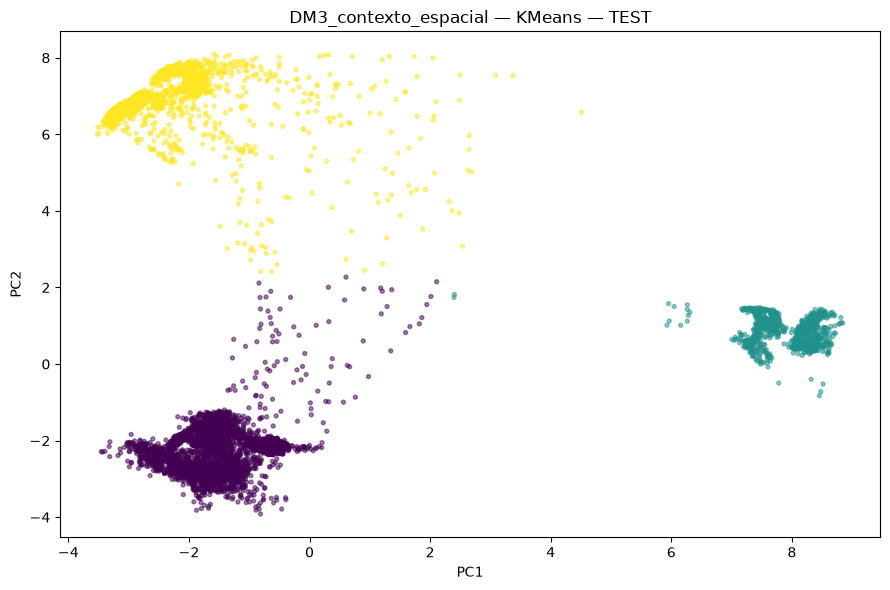

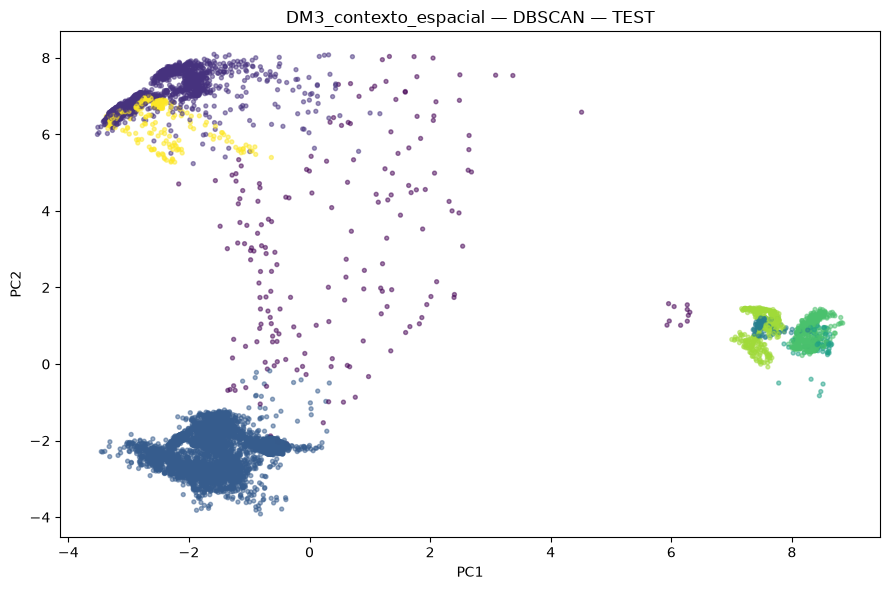

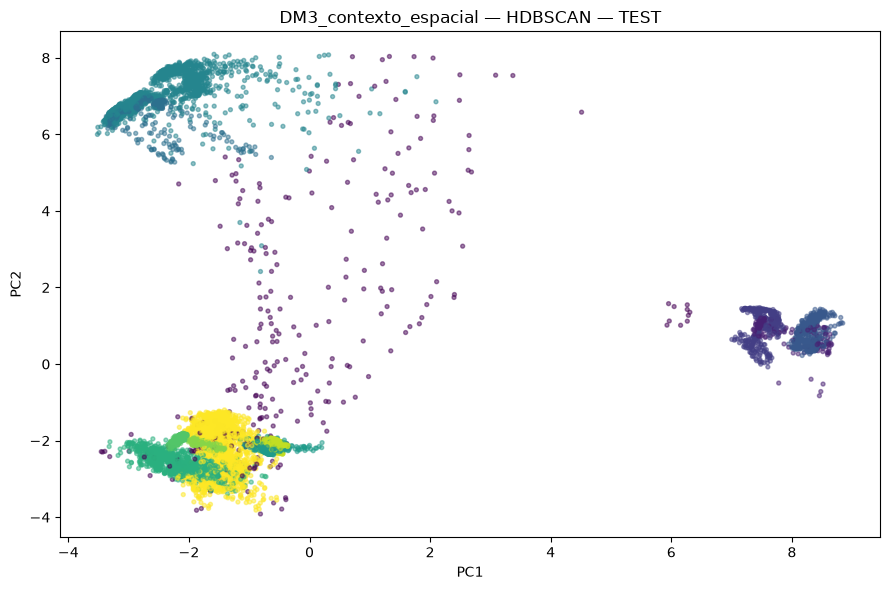

In [29]:
for mart_name, label_info in all_labels.items():

    prepared = label_info["_prepared"]

    for algorithm in [
        "KMeans",
        "DBSCAN",
        "HDBSCAN",
    ]:

        plot_clusters_pca(
            prepared=prepared,
            labels=label_info[
                algorithm
            ]["test"],
            title=(
                f"{mart_name} — "
                f"{algorithm} — TEST"
            ),
            split="test",
        )

# 16. Tablas cluster vs clase

In [30]:
def contingency_table(
    data: pd.DataFrame,
    labels: np.ndarray,
) -> pd.DataFrame:

    temp = pd.DataFrame(
        {
            "cluster": labels,
            "clase": (
                data[TARGET_COL]
                .astype(str)
                .to_numpy()
            ),
        }
    )

    return pd.crosstab(
        temp["cluster"],
        temp["clase"],
        margins=True,
    )

In [31]:
for mart_name, label_info in all_labels.items():

    prepared = label_info["_prepared"]

    print("\n" + "=" * 80)
    print(mart_name)

    for algorithm in [
        "KMeans",
        "DBSCAN",
        "HDBSCAN",
    ]:

        print(
            f"\n{algorithm} — TEST"
        )

        table = contingency_table(
            data=prepared.test_df,
            labels=label_info[
                algorithm
            ]["test"],
        )

        display(table)


DM1_fisico_completo

KMeans — TEST


clase,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
cluster,,,,,
0,98,0,4000,3000,7098
1,2669,0,0,0,2669
2,2,1059,0,0,1061
All,2769,1059,4000,3000,10828



DBSCAN — TEST


clase,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
cluster,,,,,
-1,172,10,0,1,183
0,2565,0,0,0,2565
1,0,1049,0,0,1049
2,32,0,4000,2999,7031
All,2769,1059,4000,3000,10828



HDBSCAN — TEST


...

clase,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
cluster,,,,,
0,98,0,4000,3000,7098
1,2,1059,0,0,1061
2,2669,0,0,0,2669
All,2769,1059,4000,3000,10828



DBSCAN — TEST


clase,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
cluster,,,,,
-1,174,10,0,1,185
0,1798,0,0,0,1798
1,28,0,4000,2999,7027
2,0,102,0,0,102
3,0,63,0,0,63
4,0,538,0,0,538
5,0,346,0,0,346
6,769,0,0,0,769
All,2769,1059,4000,3000,10828



HDBSCAN — TEST


clase,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
cluster,,,,,
-1,194,10,0,121,325
0,0,165,0,0,165
1,0,346,0,0,346
2,0,538,0,0,538
3,769,0,0,0,769
4,1806,0,0,0,1806
5,0,0,1000,0,1000
6,0,0,0,976,976
7,0,0,1000,0,1000


# 17. Estructura por dominio

In [32]:
def domain_cluster_report(
    data: pd.DataFrame,
    labels: np.ndarray,
) -> pd.DataFrame:

    temp = data[
        [DOMAIN_COL, TARGET_COL]
    ].copy()

    temp["cluster"] = labels

    rows = []

    for domain, subset in temp.groupby(
        DOMAIN_COL
    ):

        n_clusters = (
            subset.loc[
                subset["cluster"] != -1,
                "cluster",
            ]
            .nunique()
        )

        noise_fraction = float(
            (
                subset["cluster"]
                == -1
            ).mean()
        )

        rows.append(
            {
                "salar": domain,
                "n_clusters": int(
                    n_clusters
                ),
                "noise_fraction": noise_fraction,
            }
        )

    return pd.DataFrame(rows)

In [33]:
domain_reports = []

for mart_name, label_info in all_labels.items():

    prepared = label_info["_prepared"]

    for algorithm in [
        "KMeans",
        "DBSCAN",
        "HDBSCAN",
    ]:

        report = domain_cluster_report(
            data=prepared.test_df,
            labels=label_info[
                algorithm
            ]["test"],
        )

        report["data_mart"] = mart_name
        report["algorithm"] = algorithm

        domain_reports.append(report)

domain_structure_df = pd.concat(
    domain_reports,
    ignore_index=True,
)

display(
    domain_structure_df[
        [
            "data_mart",
            "algorithm",
            "salar",
            "n_clusters",
            "noise_fraction",
        ]
    ]
)

,data_mart,algorithm,salar,n_clusters,noise_fraction
0,DM1_fisico_completo,KMeans,hombre_muerto,3,0.000000
1,DM1_fisico_completo,KMeans,olaroz,3,0.000000
2,DM1_fisico_completo,DBSCAN,hombre_muerto,3,0.000196
3,DM1_fisico_completo,DBSCAN,olaroz,3,0.031857
4,DM1_fisico_completo,HDBSCAN,hombre_muerto,6,0.273314
5,DM1_fisico_completo,HDBSCAN,olaroz,5,0.211973
6,DM2_indices_compacto,KMeans,hombre_muerto,3,0.000000
7,DM2_indices_compacto,KMeans,olaroz,3,0.000000
8,DM2_indices_compacto,DBSCAN,hombre_muerto,4,0.008407
9,DM2_indices_compacto,DBSCAN,olaroz,4,0.049361


# 18. Ranking exploratorio

No existe una métrica única y universal para elegir "el mejor" clustering.

Se muestra un score auxiliar:

`NMI clase - NMI dominio`

Es únicamente una ayuda diagnóstica, no una métrica estándar.

In [34]:
ranking = (
    results_df[
        results_df["split"] == "test"
    ]
    .copy()
)

ranking["diagnostic_score"] = (
    ranking["nmi_class"]
    - ranking["nmi_domain"]
)

ranking = ranking.sort_values(
    [
        "diagnostic_score",
        "silhouette",
    ],
    ascending=[
        False,
        False,
    ],
)

display(
    ranking[
        [
            "data_mart",
            "algorithm",
            "n_clusters",
            "noise_fraction",
            "silhouette",
            "ari_class",
            "nmi_class",
            "nmi_domain",
            "diagnostic_score",
        ]
    ]
)

,data_mart,algorithm,n_clusters,noise_fraction,silhouette,ari_class,nmi_class,nmi_domain,diagnostic_score
3,DM1_fisico_completo,DBSCAN,3,0.016901,0.906871,0.567153,0.773900,0.040567,0.733332
9,DM2_indices_compacto,DBSCAN,4,0.030015,0.836031,0.560032,0.771467,0.043683,0.727784
1,DM1_fisico_completo,KMeans,3,0.000000,0.893991,0.557982,0.752835,0.042405,0.710429
13,DM3_contexto_espacial,KMeans,3,0.000000,0.703039,0.557982,0.752835,0.042405,0.710429
7,DM2_indices_compacto,KMeans,3,0.000000,0.901947,0.558489,0.751666,0.042586,0.709080
5,DM1_fisico_completo,HDBSCAN,6,0.240949,0.796945,0.650623,0.798985,0.335172,0.463814
15,DM3_contexto_espacial,DBSCAN,7,0.017085,0.602540,0.494794,0.692831,0.268756,0.424075
11,DM2_indices_compacto,HDBSCAN,7,0.301071,0.700552,0.563237,0.755776,0.363040,0.392736
17,DM3_contexto_espacial,HDBSCAN,11,0.030015,0.250610,0.487832,0.731394,0.470519,0.260875


# 19. Exportación

In [35]:
RESULTS_PATH = (
    OUTPUT_DIR
    / "resultados_clustering.csv"
)

PARAMETERS_PATH = (
    OUTPUT_DIR
    / "parametros_seleccionados.json"
)

SPLIT_PATH = (
    OUTPUT_DIR
    / "split_poligonos.csv"
)

DOMAIN_STRUCTURE_PATH = (
    OUTPUT_DIR
    / "estructura_clusters_por_dominio.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False,
)

split_polygons.to_csv(
    SPLIT_PATH,
    index=False,
)

domain_structure_df.to_csv(
    DOMAIN_STRUCTURE_PATH,
    index=False,
)

with open(
    PARAMETERS_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        all_parameters,
        file,
        ensure_ascii=False,
        indent=4,
    )

print("✓ Resultados exportados")

✓ Resultados exportados


# 20. Exportar labels para auditoría

In [36]:
for mart_name, label_info in all_labels.items():

    prepared = label_info["_prepared"]

    train_export = (
        prepared.train_df[
            [
                ID_COL,
                GROUP_COL,
                DOMAIN_COL,
                TARGET_COL,
            ]
        ]
        .copy()
    )

    test_export = (
        prepared.test_df[
            [
                ID_COL,
                GROUP_COL,
                DOMAIN_COL,
                TARGET_COL,
            ]
        ]
        .copy()
    )

    train_export["split"] = "train"
    test_export["split"] = "test"

    for algorithm in [
        "KMeans",
        "DBSCAN",
        "HDBSCAN",
    ]:

        train_export[
            f"cluster_{algorithm.lower()}"
        ] = label_info[
            algorithm
        ]["train"]

        test_export[
            f"cluster_{algorithm.lower()}"
        ] = label_info[
            algorithm
        ]["test"]

    labels_export = pd.concat(
        [
            train_export,
            test_export,
        ],
        ignore_index=True,
    )

    safe_name = mart_name.lower()

    labels_export.to_csv(
        OUTPUT_DIR
        / f"labels_{safe_name}.csv",
        index=False,
    )

# 21. Interpretación

## K-Means
Es el baseline más limpio para evaluar estructura aproximadamente convexa.

Como permite `predict`, el resultado de TEST es realmente fuera de muestra.

## DBSCAN
Es útil para detectar ruido y clusters no esféricos, pero puede ser muy sensible a `eps`.

## HDBSCAN
Es especialmente interesante cuando existen densidades variables y regiones ambiguas.

## Transferencia
Este notebook evalúa estabilidad no supervisada.

La prueba fuerte de transferencia se realizará luego con:

```text
Train Olaroz -> Test Hombre Muerto
Train Hombre Muerto -> Test Olaroz
```

siempre manteniendo `polygon_id` como unidad indivisible.

In [37]:
print("NOTEBOOK 02 FINALIZADO")
print("=" * 70)

print("\nResultados:")
print(RESULTS_PATH.resolve())

print("\nSplit de polígonos:")
print(SPLIT_PATH.resolve())

print("\nParámetros:")
print(PARAMETERS_PATH.resolve())

print("\nEstructura por dominio:")
print(DOMAIN_STRUCTURE_PATH.resolve())

print("\nCarpeta completa:")
print(OUTPUT_DIR.resolve())

NOTEBOOK 02 FINALIZADO

Resultados:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_unsupervised\resultados_clustering.csv

Split de polígonos:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_unsupervised\split_poligonos.csv

Parámetros:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_unsupervised\parametros_seleccionados.json

Estructura por dominio:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_unsupervised\estructura_clusters_por_dominio.csv

Carpeta completa:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_unsupervised
